In [4]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv('mel_dataset.csv', low_memory=False)

In [6]:
feature_cols = [col for col in df.columns if col.startswith('mel_')]
X = df[feature_cols].values
y = df['Ragas'].values
print("Shape of X before reshape:", X.shape)
print("Shape of y before encode:", y.shape)

Shape of X before reshape: (170, 165376)
Shape of y before encode: (170,)


In [9]:
# 2. Preprocessing
# Reshape the Mel Spectrograms into a 2D format
X_reshaped = X.reshape(170, 128, 1292, 1)
print("Shape of X after reshape:", X_reshaped.shape)

Shape of X after reshape: (170, 128, 1292, 1)


In [10]:
# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))
y_categorical = to_categorical(y_encoded, num_classes=num_classes)
print("Shape of y_categorical before split:", y_categorical.shape)

Shape of y_categorical before split: (170, 9)


In [11]:
print(num_classes)

9


In [12]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_reshaped, y_categorical, test_size=0.2, random_state=42)

In [13]:
#2D CNN Model
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        # Convolutional Block 1
        Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # Convolutional Block 2
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5), # Dropout for regularization
        Dense(num_classes, activation='softmax') # Output layer
    ])
    return model

In [14]:
input_shape = (128, 1292, 1)
model = create_cnn_model(input_shape, num_classes=9)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 1290, 64)  │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 645, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 643, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 321, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1232640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   315,556,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,632,905 (1.18 GB)

 Trainable params: 315,632,905 (1.18 GB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train, y_train,epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.1630 - loss: 1597.7866 - val_accuracy: 0.2647 - val_loss: 107.2972
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.2841 - loss: 68.9102 - val_accuracy: 0.4118 - val_loss: 6.9492
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 289ms/step - accuracy: 0.6168 - loss: 7.1288 - val_accuracy: 0.3824 - val_loss: 5.1959
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 306ms/step - accuracy: 0.6095 - loss: 5.8653 - val_accuracy: 0.4706 - val_loss: 3.5870
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.6709 - loss: 2.7387 - val_accuracy: 0.6176 - val_loss: 1.5062
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 302ms/step - accuracy: 0.8425 - loss: 1.1549 - val_accuracy: 0.5588 - val_loss: 1.3699
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.8840 - loss: 0.7761 - val_accuracy: 0.6176 - val_loss: 1.3071
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.9513 - loss: 0.1520 - val_accuracy: 0.5882 - val_l

In [18]:
# 5. Evaluate the Model
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Loss: 1.8258
Validation Accuracy: 0.6765


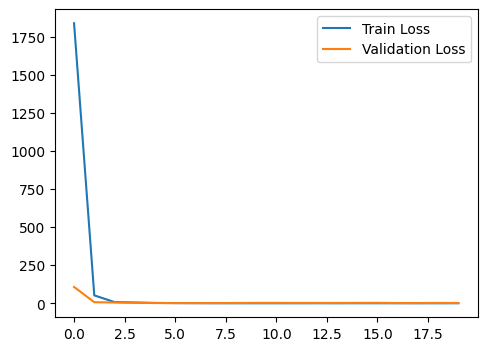

In [19]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

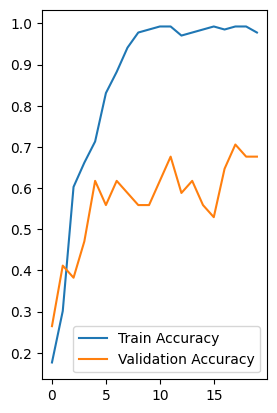

In [20]:
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [21]:
test_df = pd.read_csv('mel_test_dataset.csv')

In [22]:
feature_cols_test = [col for col in test_df.columns if col.startswith('mel_')]
X_test = test_df[feature_cols].values
y_test = test_df['Ragas'].values
print("Shape of X before reshape:", X_test.shape)
print("Shape of y before encode:", y_test.shape)

Shape of X before reshape: (94, 165376)
Shape of y before encode: (94,)


In [23]:
X_test_reshaped = X_test.reshape(94, 128, 1292, 1)
print("Shape of test X after reshape:", X_test_reshaped.shape)

Shape of test X after reshape: (94, 128, 1292, 1)


In [24]:
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)
num_classes = len(np.unique(y_test_encoded))
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)
print("Shape of y_categorical before split:", y_test_categorical.shape)

Shape of y_categorical before split: (94, 9)


In [26]:
predictions = model.predict(X_test_reshaped)

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


In [27]:
# Evaluate the model
try:
    loss, accuracy = model.evaluate(X_test_reshaped, y_test_categorical, verbose=0)
    print(f'Test Loss: {loss:.4f}')
    print(f'Test Accuracy: {accuracy:.4f}')
except ValueError as e:
    print(f"Error during evaluation: {e}")

Test Loss: 1.6280
Test Accuracy: 0.7660


In [28]:
predicted_classes = np.argmax(predictions, axis=1)
original_predicted_classes = label_encoder.inverse_transform(predicted_classes)

print("Predicted Classes:", original_predicted_classes)

Predicted Classes: ['Asavari' 'Asavari' 'Asavari' 'Asavari' 'Asavari' 'Asavari' 'Asavari'
 'Asavari' 'Asavari' 'Asavari' 'Bageshree' 'Bageshree' 'Bageshree'
 'Bageshree' 'Bageshree' 'Bhoopali' 'Yaman' 'Bageshree' 'Bageshree'
 'Bageshree' 'Bageshree' 'Bageshree' 'Yaman' 'Yaman' 'Yaman' 'Yaman'
 'Yaman' 'Yaman' 'Bhoopali' 'Yaman' 'Asavari' 'Yaman' 'Yaman' 'Bhairavi'
 'Bhairavi' 'Bhairavi' 'Bhairavi' 'Yaman' 'Bhairavi' 'Bhairavi' 'Bhairavi'
 'Bhairavi' 'Bhairavi' 'Bhairavi' 'Bhoopali' 'Bhoopali' 'Yaman' 'Bhoopali'
 'Bhoopali' 'Bhoopali' 'Bhoopali' 'Bhoopali' 'Bhoopali' 'Bhoopali' 'Yaman'
 'Darbari' 'Darbari' 'Darbari' 'Darbari' 'Darbari' 'Darbari' 'Darbari'
 'Darbari' 'Darbari' 'Bageshree' 'Bageshree' 'Malkauns' 'Yaman' 'Malkauns'
 'Malkauns' 'Malkauns' 'Malkauns' 'Malkauns' 'Malkauns' 'Sarang'
 'Bageshree' 'Sarang' 'Sarang' 'Sarang' 'Sarang' 'Sarang' 'Sarang'
 'Sarang' 'Sarang' 'Yaman' 'Yaman' 'Yaman' 'Yaman' 'Bhoopali' 'Yaman'
 'Yaman' 'Yaman' 'Yaman' 'Yaman']



Classification Report:
              precision    recall  f1-score   support

     Asavari       0.91      1.00      0.95        10
   Bageshree       0.77      0.83      0.80        12
    Bhairava       0.00      0.00      0.00        12
    Bhairavi       0.90      0.90      0.90        10
    Bhoopali       0.75      0.90      0.82        10
     Darbari       1.00      0.90      0.95        10
    Malkauns       1.00      0.70      0.82        10
      Sarang       1.00      0.90      0.95        10
       Yaman       0.39      0.90      0.55        10

    accuracy                           0.77        94
   macro avg       0.75      0.78      0.75        94
weighted avg       0.73      0.77      0.73        94



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


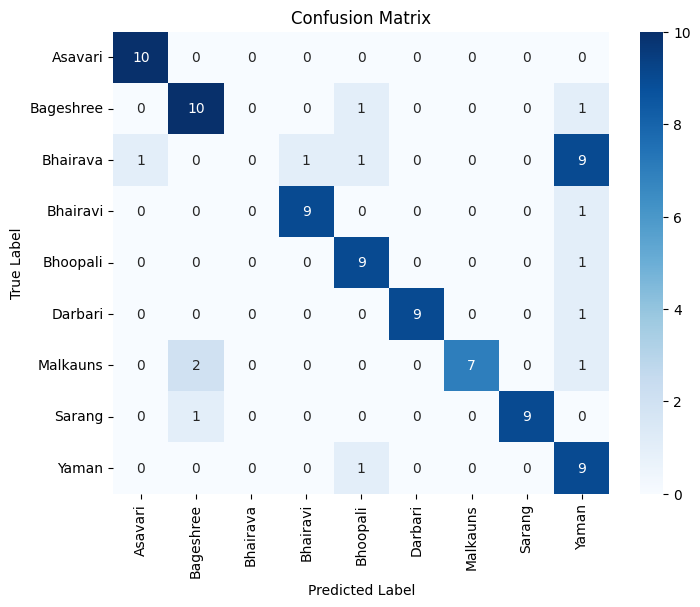

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nClassification Report:")
print(classification_report(y_test, original_predicted_classes))
cm = confusion_matrix(y_test, original_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()